2021-11-30 ~ 2023-12-01 까지 2년치 매일 30건씩

주차로 묶어서 시각화

# Figure 1(Difficulty)

In [1]:
import pandas as pd
import re
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import lib.stats.stats as st
import lib.annotation.Result_Prep as rp
import config.config as conf
import matplotlib as mpl
import matplotlib.lines as mlines
import os

INFO 01-05 21:03:21 [__init__.py:216] Automatically detected platform cuda.


In [2]:
path = f'{conf.DATA_PATH}/data/llm_annotation_result' 
file_list = os.listdir(path)

In [3]:
r_p = rp.Result_Prep()

In [4]:
ver_list = sorted([y for y in [x for x in file_list if x.isdigit()] if (int(y)>=200000) & (int(y)<300000)])

In [5]:
print(ver_list)

['200037', '200038', '200039', '200040', '200041', '200042', '200043', '200044', '200045', '200046', '200047', '200048', '200049', '200050', '200051', '200052', '200053', '200054', '200055', '200056', '200057', '200058', '200059', '200060', '200061', '200062', '200063', '200064', '200065', '200066', '200067', '200068', '200070', '200071', '200073']


In [6]:
tot_calc = pd.DataFrame()
for listid in ver_list:
    df = r_p.make_one_file(listid, path)
    if isinstance(df, pd.core.frame.DataFrame):
        df = r_p.pp_df(df, 5)
        df = r_p.calc_rate_byweek(df)
        tot_calc = pd.concat([tot_calc, df], axis = 0)

    

In [7]:
tot_calc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 0 to 2
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rel_week  105 non-null    float64
 1   o_result  105 non-null    object 
 2   r_cnt     105 non-null    int64  
 3   tot_cnt   105 non-null    int64  
 4   rate      105 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 4.9+ KB


In [8]:
m_chk_cnt_0 = tot_calc[tot_calc['o_result'] =='0']
m_chk_cnt_1 = tot_calc[tot_calc['o_result'] =='1']
m_chk_cnt_2 = tot_calc[tot_calc['o_result'] =='2']

In [9]:
m_chk_cnt_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 0 to 0
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rel_week  35 non-null     float64
 1   o_result  35 non-null     object 
 2   r_cnt     35 non-null     int64  
 3   tot_cnt   35 non-null     int64  
 4   rate      35 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 1.6+ KB


In [10]:
print(m_chk_cnt_0.loc[m_chk_cnt_0['o_result'].isna(), 'rate'])
print(m_chk_cnt_1.loc[m_chk_cnt_1['o_result'].isna(), 'rate'])
print(m_chk_cnt_2.loc[m_chk_cnt_2['o_result'].isna(), 'rate'])

Series([], Name: rate, dtype: float64)
Series([], Name: rate, dtype: float64)
Series([], Name: rate, dtype: float64)


In [11]:
m_chk_cnt_0.loc[:, 'o_result'] = '0'
m_chk_cnt_1.loc[:, 'o_result'] = '1'
m_chk_cnt_2.loc[:, 'o_result'] = '2'

In [12]:
def calc_stats(df):
    x = df['rel_week'].values
    y = df['rate'].values
    st_ = st.Stats(x, y, 2, 0.95)
    F_stat, p_value = st_.chow_test()

    return x, y, st_, F_stat, p_value


In [13]:
x = m_chk_cnt_0[(m_chk_cnt_0['rel_week'] >=-52) & (m_chk_cnt_0['rel_week'] <52)].rel_week.values

In [14]:
x[:13]

array([-50., -45., -41., -37., -32., -28., -24., -19., -15., -11.,  -6.,
        -2.,   2.])

In [15]:
result_dict = \
{0 : {0:  calc_stats(m_chk_cnt_0[(m_chk_cnt_0['rel_week'] >=-52) & (m_chk_cnt_0['rel_week'] <52)]),
        1 : calc_stats(m_chk_cnt_0[(m_chk_cnt_0['rel_week'] >=0) & (m_chk_cnt_0['rel_week'] <104)])},

1 : {0:  calc_stats(m_chk_cnt_1[(m_chk_cnt_1['rel_week'] >=-52) & (m_chk_cnt_1['rel_week'] <52)]),
       1:  calc_stats(m_chk_cnt_1[(m_chk_cnt_1['rel_week'] >= 0) & (m_chk_cnt_1['rel_week'] < 104)])},

2 : {0:  calc_stats(m_chk_cnt_2[(m_chk_cnt_2['rel_week'] >=-52) & (m_chk_cnt_2['rel_week'] <52)]),
       1:  calc_stats(m_chk_cnt_2[(m_chk_cnt_2['rel_week'] >= 0) & (m_chk_cnt_2['rel_week'] < 104)])}
}

In [20]:
result_dict

{0: {0: (array([-50., -45., -41., -37., -32., -28., -24., -19., -15., -11.,  -6.,
           -2.,   2.,   7.,  11.,  15.,  20.,  24.,  28.,  33.,  37.,  42.,
           46.,  50.]),
   array([78.57142857, 81.63265306, 79.7979798 , 91.83673469, 78.35051546,
          83.50515464, 87.        , 82.4742268 , 77.77777778, 84.21052632,
          82.82828283, 89.36170213, 86.86868687, 77.08333333, 67.67676768,
          82.10526316, 77.08333333, 72.91666667, 75.75757576, 80.6122449 ,
          80.6122449 , 79.7979798 , 69.14893617, 73.19587629]),
   np.float64(1.8786867048737512),
   np.float64(0.17877867672955838)),
  1: (array([  2.,   7.,  11.,  15.,  20.,  24.,  28.,  33.,  37.,  42.,  46.,
           50.,  55.,  59.,  63.,  68.,  72.,  76.,  81.,  89.,  94., 103.]),
   array([86.86868687, 77.08333333, 67.67676768, 82.10526316, 77.08333333,
          72.91666667, 75.75757576, 80.6122449 , 80.6122449 , 79.7979798 ,
          69.14893617, 73.19587629, 69.14893617, 82.65306122, 73.46938776,


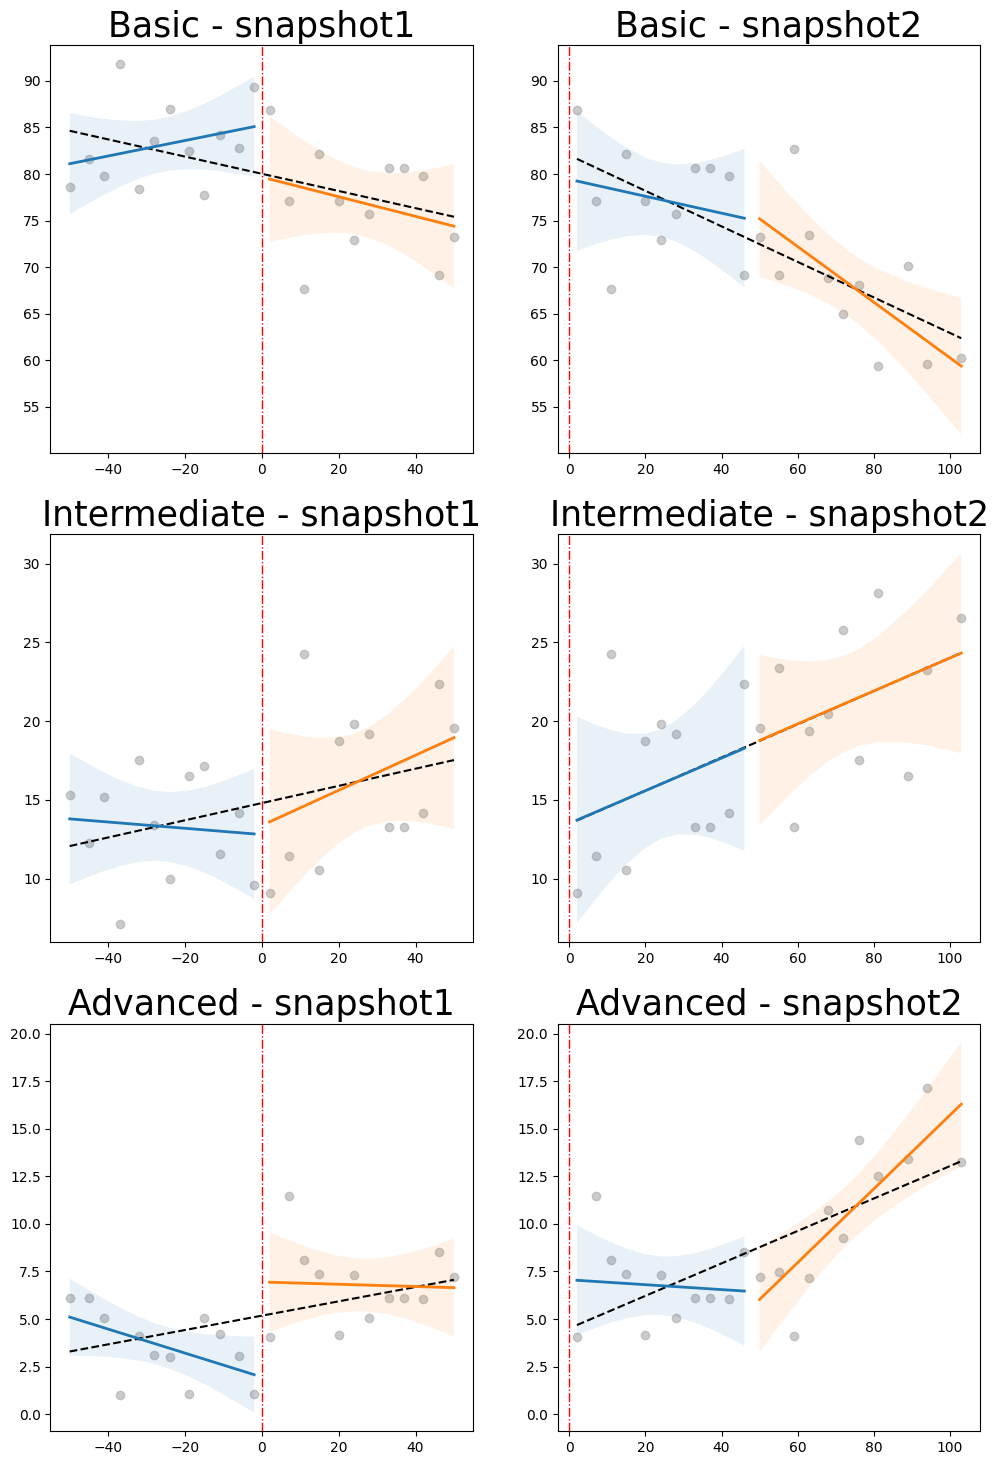

In [34]:
fig, axs = plt.subplots(3, 2, figsize = (12, 18))

diff_dict = {0 : 'Basic', 1 : 'Intermediate', 2 : 'Advanced'}
snapshot_dict = {0 : 'snapshot1', 1 : 'snapshot2'}
for i in range(3):
    axs[i, 1].sharey(axs[i, 0])

for x_idx, snap_dict in result_dict.items():
    for y_idx, st_param in snap_dict.items():
        x = st_param[0]
        split_idx = int(len(x)/2)
        x_0_1 = x[:split_idx]
        x_0_2 = x[split_idx:]

        axs[x_idx][y_idx].scatter(st_param[0], st_param[1],  alpha=0.6, color='darkgray')
        axs[x_idx][y_idx].plot(st_param[0], st_param[2].y_predict, label="Overall Fit", linestyle="--", color="black")  

        axs[x_idx][y_idx].plot(x_0_1, st_param[2].y1_predict, label="before ChatGPT", linewidth='2')
        axs[x_idx][y_idx].fill_between(x_0_1, st_param[2].y1_predict - st_param[2].y1_conf_interval, st_param[2].y1_predict + st_param[2].y1_conf_interval, alpha=0.1)

        axs[x_idx][y_idx].plot(x_0_2, st_param[2].y2_predict, label="after ChatGPT", linewidth='2')
        axs[x_idx][y_idx].fill_between(x_0_2, st_param[2].y2_predict - st_param[2].y2_conf_interval, st_param[2].y2_predict + st_param[2].y2_conf_interval, alpha=0.1)

        axs[x_idx][y_idx].axvline(x=0,     color='red',    linestyle='-.', linewidth=1)
        axs[x_idx][y_idx].set_title(f"{diff_dict[x_idx]} - {snapshot_dict[y_idx]}", fontsize=25)
        